In [1]:
from geostat_isoscapes_tools import utils,sisal_utils, geostat_utils, plot_utils
import numpy as np
from pykrige.uk import UniversalKriging
import json
from scipy.interpolate import griddata
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style('dark')

In [2]:
regions = None#('continents',['Asia']) #('continents',['Asia','Europe','South America','North America','Oceania'])#('countries',['United States of America']) # None #('continents',['Asia'])
buffer_km=0
qty='d18Op_VSMOW_linearized'

Load SISAL data and prepare it for kriging

In [3]:
# load calcite data, sanatize it, convert to drip water equivalents, take a temporal sclice
data_with_time_slices = geostat_utils.get_sisal_data_for_kriging(res=200,
                                                                 regions=regions,
                                                                 buffer_km=buffer_km,
                                                                 conversion=qty)

loading sisal data
-> loading SISAL database
   cleaning samples
loading and cleaning done.
-> converting speleothem data
   linear interpolation failed for 121612 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 64562 samples.
   temperature retrieval finished, starting conversion
conversion done.
sisal dataframe is ready


Select a time slice and visualize data to krige  

In [4]:
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_age']==11200)].copy()
plot_utils.plot_global_map(data_to_krige,'sISAL data to krige - 11-11.2 kyr BP',unit='‰ VSMOW',quantity_col=qty,lat_col='lat',lon_col='lon') # type:ignore

Load modern data and prepare it for being the external drift 

In [29]:
itrace_data = geostat_utils.get_preprocessed_itrace_data(res=12*200,regions=regions,buffer_km=buffer_km) # simulation 12k


loading itrace files
This dataset contains  12000  time steps.
   bins of width=2400 months (200 years)
   converting xr to DataFrame (~2 minutes)
done


In [30]:
itrace_data,_ = utils.mask_union_of_circles_around_pts(itrace_data,data_to_krige,radius_km=1500) # type:ignore

In [31]:
# number of time steps 
itrace_times = itrace_data['time'].unique() #type:ignore
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-1]].dropna() #type:ignore

plot_utils.plot_global_map(external_drift_df,'external drift','d18Op',unit='‰ VSMOW', lat_col='lat',lon_col='lon') # type:ignore

In [32]:
# if any(external_drift_df['lat']>90):
#     external_drift_df['lat']=utils.convert_lat_0_180_to_neg90_90(np.array(external_drift_df['lat'].values))
# if any(external_drift_df['lon']>180) :
#     external_drift_df['lon']=utils.convert_lon_0_360_to_neg180_180(np.array(external_drift_df['lat'].values))

Retrieve the variogram model and parameters (of itrace)

In [33]:
with open(f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_ele_D/sisal_mask/variogram_params_None.json', 'r') as f:
    variogram_dict = json.load(f)


# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": np.exp(variogram_dict['sill_ln']), 
    "range": variogram_dict['range'],  
    "nugget": np.exp(variogram_dict['nugget_ln'])+1
}

print(variogram_parameters)

{'sill': np.float64(15.317616255446127), 'range': 4160090.680266922, 'nugget': np.float64(1.0)}


In [34]:
# Retrieve itrace at observation points
import numpy as np
from scipy.spatial import cKDTree

lats_obs = data_to_krige['lat']
lons_obs  = data_to_krige['lon']


# Build tree from the grid coordinates
grid_points = np.column_stack((external_drift_df['lat'], external_drift_df['lon']))
tree = cKDTree(grid_points)

# Query nearest grid point for each observation
dists, idxs = tree.query(np.column_stack((lats_obs, lons_obs)))
itrace_at_obs_nn = external_drift_df['d18Op'].values[idxs]



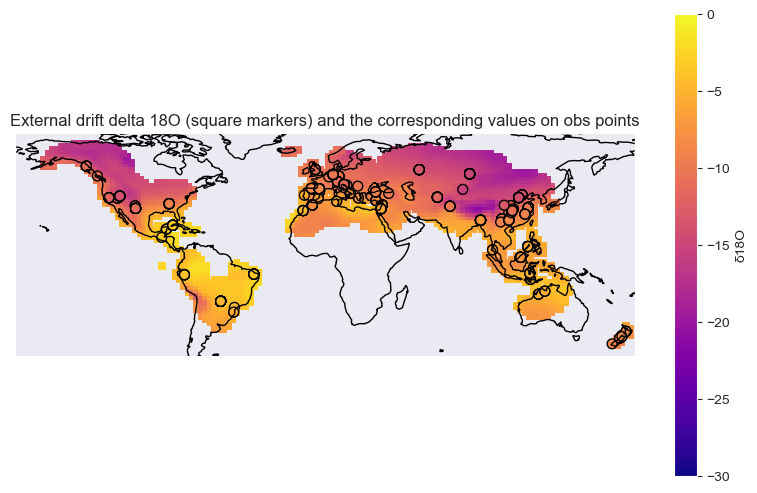

In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import Normalize

# Normalization range
vmin, vmax = -30, 0
norm = Normalize(vmin=vmin, vmax=vmax)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the "external drift" values as colored squares
scatter_drift = ax.scatter(
    external_drift_df['lon'],
    external_drift_df['lat'],
    c=external_drift_df['d18Op'],
    cmap='plasma',
    norm=norm,
    s=30,               # Adjust marker size to your data density
    marker='s',         # Square markers
    edgecolor='none',
    transform=ccrs.PlateCarree()
)

# Add colorbar
plt.colorbar(scatter_drift, ax=ax, label='δ18O')

# Optionally overlay the observation points
ax.scatter(
    lons_obs,
    lats_obs,
    c=itrace_at_obs_nn,
    cmap='plasma',
    norm=norm,
    s=50,
    edgecolor='k',
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.set_title("External drift delta 18O (square markers) and the corresponding values on obs points")
plt.show()


In [36]:
# project data in CRS system for kriging 
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['lon'].values,data_to_krige['lat'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['lon'].values,external_drift_df['lat'].values)
itrace_values_xygrid = external_drift_df['d18Op'].values

In [37]:
# KED kriging object
uk = UniversalKriging(
    x=data_to_krige["x"],
    y=data_to_krige["y"],
    z=data_to_krige[qty],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[itrace_at_obs_nn]
)

In [38]:
# Execute it 
z_pred, ss_pred = uk.execute(
    style="points",
    xpoints=external_drift_df['x'],
    ypoints=external_drift_df['y'],
    specified_drift_arrays=[itrace_values_xygrid]
)

**Plot the results**

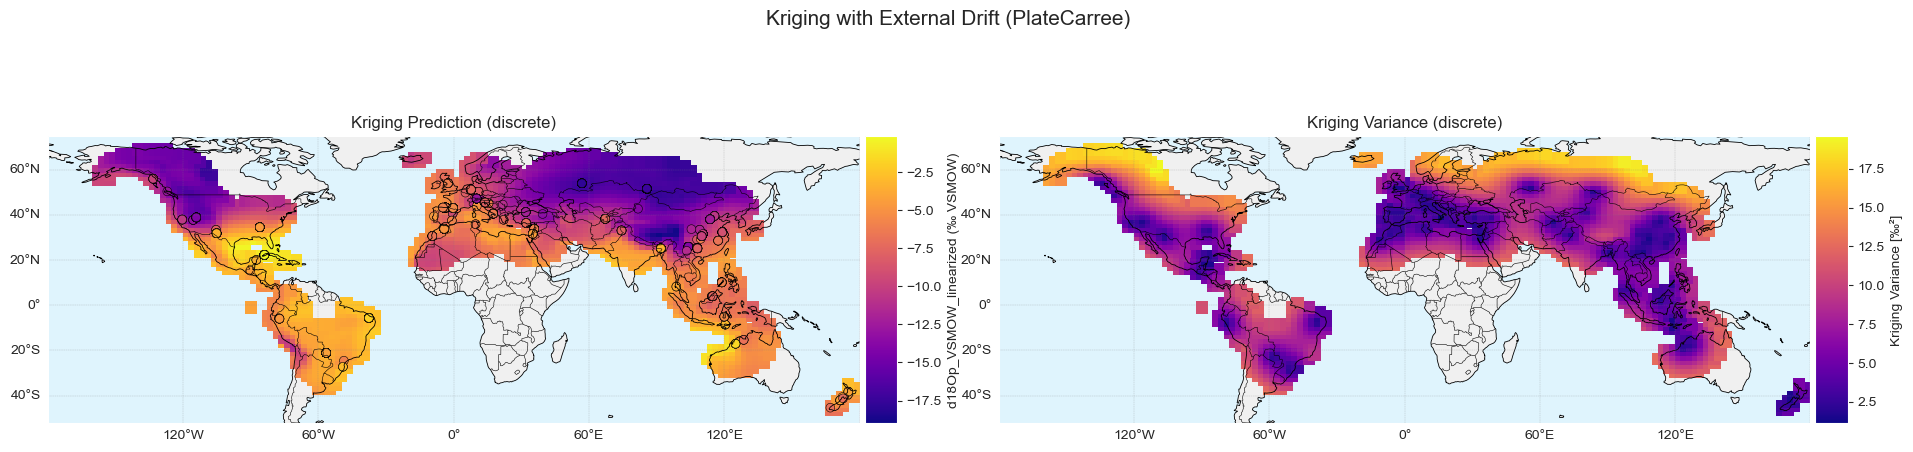

In [39]:
fig,axes = plot_utils.plot_ked_platecarree_points(
    lon_pred=external_drift_df['lon'],
    lat_pred=external_drift_df['lat'],
    z_pred=z_pred,
    ss_pred=ss_pred,
    df_exp=data_to_krige,               
    value_col=qty,
    cmap='plasma',
    s_pred=80,
    figsize=(20,6)
)
plt.show()

##### (draft of plot)

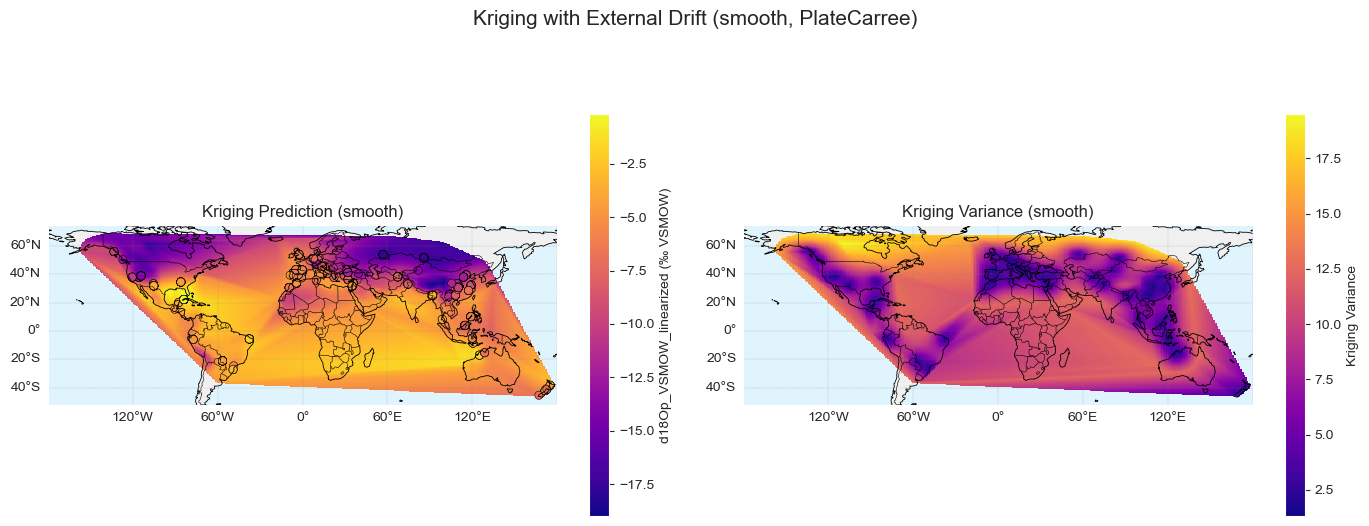

In [40]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.interpolate import griddata


def plot_ked_platecarree_smooth(
    lon_pred, lat_pred, z_pred, ss_pred,
    df_exp, value_col='d18Op_VSMOW',
    title="Kriging with External Drift (smooth, PlateCarree)",
    cmap="coolwarm",
    figsize=(14,6),
    vmin=None, vmax=None,
    res=300j,  # interpolation grid resolution (complex step)
    method='linear'
):
    """
    Plot KED kriging results as smooth continuous fields in lon/lat space.
    Fixed version: correct axis orientation, masked edges, no flipping.
    
    Parameters
    ----------
    lon_pred, lat_pred : 1D arrays of longitudes and latitudes (degrees)
    z_pred : 1D array of kriging predictions
    ss_pred : 1D array of kriging variances
    df_exp : DataFrame with observed points, must have 'longitude' and 'latitude'
    value_col : str, column in df_exp with measured isotope values
    res : grid resolution (e.g., 300j = 300x300 grid)
    method : interpolation method ('linear', 'cubic', or 'nearest')
    """

    # Handle color limits
    vmin = vmin if vmin is not None else np.nanmin(z_pred)
    vmax = vmax if vmax is not None else np.nanmax(z_pred)

    # Build regular lon/lat grid (lat first, lon second!)
    lat_min, lat_max = np.nanmin(lat_pred), np.nanmax(lat_pred)
    lon_min, lon_max = np.nanmin(lon_pred), np.nanmax(lon_pred)
    lat_grid, lon_grid = np.mgrid[
        lat_min:lat_max:res,
        lon_min:lon_max:res
    ]

    # Interpolate kriging prediction and variance
    z_grid = griddata(
        points=(lat_pred, lon_pred),
        values=z_pred,
        xi=(lat_grid, lon_grid),
        method=method
    )
    ss_grid = griddata(
        points=(lat_pred, lon_pred),
        values=ss_pred,
        xi=(lat_grid, lon_grid),
        method=method
    )

    # Mask NaNs (outside convex hull)
    z_grid = np.ma.masked_invalid(z_grid)
    ss_grid = np.ma.masked_invalid(ss_grid)

    # Create figure
    fig, axes = plt.subplots(
        1, 2, figsize=figsize,
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # Define extent with small padding
    pad_lon = (lon_max - lon_min) * 0.05
    pad_lat = (lat_max - lat_min) * 0.05
    extent = [
        lon_min - pad_lon, lon_max + pad_lon,
        lat_min - pad_lat, lat_max + pad_lat
    ]

    # Add base map features
    for ax in axes:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", edgecolor="none")
        ax.add_feature(cfeature.OCEAN, facecolor="#dff4fd", edgecolor="none")
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
        gl.right_labels = gl.top_labels = False

    # --- Left panel: Kriging prediction ---
    mesh1 = axes[0].pcolormesh(
        lon_grid, lat_grid, z_grid,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    axes[0].scatter(
        df_exp['lon'], df_exp['lat'],
        c=df_exp[value_col],
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        s=35,
        edgecolor='black',
        linewidth=0.4,
        transform=ccrs.PlateCarree()
    )
    cbar1 = plt.colorbar(mesh1, ax=axes[0], orientation='vertical', shrink=0.75, pad=0.05)
    cbar1.set_label(f"{value_col} (‰ VSMOW)")
    axes[0].set_title("Kriging Prediction (smooth)")

    # --- Right panel: Kriging variance ---
    mesh2 = axes[1].pcolormesh(
        lon_grid, lat_grid, ss_grid,
        cmap='plasma',
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    cbar2 = plt.colorbar(mesh2, ax=axes[1], orientation='vertical', shrink=0.75, pad=0.05)
    cbar2.set_label("Kriging Variance")
    axes[1].set_title("Kriging Variance (smooth)")

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


plot_ked_platecarree_smooth(
    lon_pred=external_drift_df['lon'],
    lat_pred=external_drift_df['lat'],
    z_pred=z_pred,
    ss_pred=ss_pred,
    df_exp=data_to_krige, 
    value_col=qty,
    cmap='plasma'
)

In [41]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import numpy as np

# def plot_ked_mercator(
#     xs, ys, z_pred, ss_pred,
#     df_exp, value_col='d18Op_VSMOW',
#     lon_exp=None, lat_exp=None,  # optional lon/lat for labels
#     title="Kriging with External Drift (Mercator)",
#     cmap="coolwarm",
#     figsize=(14,6),
#     vmin=None, vmax=None
# ):
#     """
#     Plot KED kriging results in Mercator projection with variance map
#     and overlay experimental points.
    
#     Parameters
#     ----------
#     xs, ys : 1D arrays of x/y coordinates in meters (Mercator CRS system)
#     z_pred : 2D array of kriging predictions
#     ss_pred : 2D array of kriging variances
#     df_exp : DataFrame of experimental points, must contain value_col
#     value_col : column in df_exp to use to find the values at observation points
#     lon_exp, lat_exp : optional, for display (not needed for projection)
#     """
    
#     fig, axes = plt.subplots(
#         1, 2, figsize=figsize,
#         subplot_kw={'projection': ccrs.Mercator()}
#     )
    
#     # Set extent in Mercator coordinates
#     for ax in axes:
#         ax.set_extent([
#             xs.min()-300000, xs.max()+300000,
#             ys.min()-300000, ys.max()+300000
#         ], crs=ccrs.Mercator())
#         ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
#         ax.add_feature(cfeature.BORDERS, linewidth=0.4)
#         ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", edgecolor="none")
#         ax.add_feature(cfeature.OCEAN, facecolor="#dff4fd", edgecolor="none")
#         gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
#         gl.right_labels = gl.top_labels = False
    
#     # Create meshgrid for pcolormesh
#     X, Y = np.meshgrid(xs.unique().sort(), ys.unique().sort())
    
#     # Left: KED predictions
#     mesh = axes[0].pcolormesh(
#         X, Y, z_pred,
#         transform=ccrs.Mercator(),
#         shading='auto',
#         cmap=cmap,
#         vmin=vmin if vmin is not None else np.nanmin(z_pred),
#         vmax=vmax if vmax is not None else np.nanmax(z_pred)
#     )
    
#     # Overlay experimental points
#     axes[0].scatter(
#         df_exp['x'], df_exp['y'],
#         c=df_exp[value_col],
#         s=25,
#         edgecolor='black',
#         linewidth=0.5,
#         cmap=cmap,
#         vmin=vmin,
#         vmax=vmax,
#         transform=ccrs.Mercator()
#     )
    
#     cbar = plt.colorbar(mesh, ax=axes[0], orientation='vertical', shrink=0.75, pad=0.05)
#     cbar.set_label(f"{value_col} (‰ VSMOW)")
#     axes[0].set_title("Kriging Prediction")
    
#     # Right: Kriging variance
#     mesh2 = axes[1].pcolormesh(
#         X, Y, ss_pred,
#         transform=ccrs.Mercator(),
#         shading='auto',
#         cmap='viridis'
#     )
#     cbar2 = plt.colorbar(mesh2, ax=axes[1], orientation='vertical', shrink=0.75, pad=0.05)
#     cbar2.set_label("Kriging Variance")
#     axes[1].set_title("Kriging Variance")
    
#     fig.suptitle(title, fontsize=15)
#     plt.tight_layout()
#     plt.show()


# plot_ked_mercator(
#     xs=external_drift_df['x'],
#     ys=external_drift_df['y'],
#     z_pred=z_pred,
#     ss_pred=ss_pred,
#     df_exp=data_to_krige,
#     value_col=conversion,
#     cmap="coolwarm"
# )